# Human Activity Recognition Using Hidden Markov Models

This notebook implements a full pipeline for recognizing human activities (Still, Standing, Walking, Jumping) from smartphone accelerometer and gyroscope signals using Hidden Markov Models (HMMs).


## Section 0: Install & Import Dependencies

In [25]:
# Install required libraries
!pip install hmmlearn scikit-learn pandas numpy matplotlib seaborn scipy -q

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn import hmm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.



## Section 1 — Data Loading & Preprocessing

### 1.1 Configuration

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Base dataset path in Google Drive
BASE_PATH = "/content/drive/MyDrive/data"

# Paths
TRAIN_ROOT = os.path.join(BASE_PATH, "train")
TEST_ROOT  = os.path.join(BASE_PATH, "test")

In [29]:
print("Train path:", TRAIN_ROOT)
print("Test path :", TEST_ROOT)
print("Train exists:", os.path.exists(TRAIN_ROOT))
print("Test exists :", os.path.exists(TEST_ROOT))

Train path: /content/drive/MyDrive/data/train
Test path : /content/drive/MyDrive/data/test
Train exists: True
Test exists : True


In [30]:


# Activity labels (canonical lowercase)
ACTIVITIES     = ['still', 'standing', 'walking', 'jumping']
ACTIVITY_TO_ID = {a: i for i, a in enumerate(ACTIVITIES)}
ID_TO_ACTIVITY = {i: a for a, i in ACTIVITY_TO_ID.items()}

# Signal processing
# resample everything to 50 Hz so all feature windows are consistent.
TARGET_FS   = 50    # Hz — common resampled rate
WINDOW_SIZE = 50    # samples = 1 second at 50 Hz
STEP_SIZE   = 25    # 50% overlap gives more training windows per recording

print(f"Target sampling rate : {TARGET_FS} Hz")
print(f"Window size          : {WINDOW_SIZE} samples = {WINDOW_SIZE/TARGET_FS:.1f} second")
print(f"Step size            : {STEP_SIZE} samples = {STEP_SIZE/TARGET_FS:.2f} s (50% overlap)")
print()
print("Window size justification:")
print("  At 50 Hz, 50 samples = 1 second per window.")
print("  1 second is long enough to capture a full stride (walking)")
print("  or jump cycle, while short enough to stay within a single activity.")
print("  50% overlap maximises the number of training windows without")
print("  introducing excessive redundancy.")

Target sampling rate : 50 Hz
Window size          : 50 samples = 1.0 second
Step size            : 25 samples = 0.50 s (50% overlap)

Window size justification:
  At 50 Hz, 50 samples = 1 second per window.
  1 second is long enough to capture a full stride (walking)
  or jump cycle, while short enough to stay within a single activity.
  50% overlap maximises the number of training windows without
  introducing excessive redundancy.


### 1.2 Load & Merge a Single Recording

In [31]:
def load_recording(sample_dir):
    """
    Loads Accelerometer.csv and Gyroscope.csv from `sample_dir`,
    merges on a common time axis using linear interpolation,
    resamples to TARGET_FS Hz.

    Returns:
        (merged_df, native_fs_accel, native_fs_gyro)
        or None if files are missing / unreadable.

    merged_df columns: t, accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z
    """
    acc_path = os.path.join(sample_dir, 'Accelerometer.csv')
    gyr_path = os.path.join(sample_dir, 'Gyroscope.csv')

    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        return None

    try:
        acc = pd.read_csv(acc_path)
        gyr = pd.read_csv(gyr_path)
    except Exception:
        return None

    # Normalise column names
    acc.columns = acc.columns.str.lower().str.strip()
    gyr.columns = gyr.columns.str.lower().str.strip()

    if 'seconds_elapsed' not in acc.columns or 'seconds_elapsed' not in gyr.columns:
        return None

    acc = acc.rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
    gyr = gyr.rename(columns={'x': 'gyro_x',  'y': 'gyro_y',  'z': 'gyro_z'})

    acc = acc[['seconds_elapsed', 'accel_x', 'accel_y', 'accel_z']].dropna()
    gyr = gyr[['seconds_elapsed', 'gyro_x',  'gyro_y',  'gyro_z']].dropna()

    # Detect native sampling rates from median time difference
    fs_acc = 1.0 / np.median(np.diff(acc['seconds_elapsed'].values))
    fs_gyr = 1.0 / np.median(np.diff(gyr['seconds_elapsed'].values))

    # Common time axis (overlap region only)
    t_start = max(acc['seconds_elapsed'].iloc[0],  gyr['seconds_elapsed'].iloc[0])
    t_end   = min(acc['seconds_elapsed'].iloc[-1], gyr['seconds_elapsed'].iloc[-1])
    if t_end <= t_start:
        return None

    t_new = np.arange(t_start, t_end, 1.0 / TARGET_FS)

    def resample_sensor(df, time_col, value_cols, t_new):
        t = df[time_col].values
        out = {'t': t_new}
        for col in value_cols:
            f = interp1d(t, df[col].values, kind='linear',
                         bounds_error=False, fill_value='extrapolate')
            out[col] = f(t_new)
        return pd.DataFrame(out)

    acc_r = resample_sensor(acc, 'seconds_elapsed',
                            ['accel_x', 'accel_y', 'accel_z'], t_new)
    gyr_r = resample_sensor(gyr, 'seconds_elapsed',
                            ['gyro_x', 'gyro_y', 'gyro_z'], t_new)

    merged = acc_r.copy()
    merged['gyro_x'] = gyr_r['gyro_x'].values
    merged['gyro_y'] = gyr_r['gyro_y'].values
    merged['gyro_z'] = gyr_r['gyro_z'].values

    return merged, round(fs_acc), round(fs_gyr)


print("load_recording() defined.")

load_recording() defined.


### 1.3 Scan Dataset & Report Sampling Rates

In [32]:
def scan_dataset(root):
    """
    Walk directory tree under `root`.
    Returns list of (sample_dir, activity_label, participant) tuples.
    Handles both lowercase and capitalised folder names.
    """
    samples = []
    for participant in sorted(os.listdir(root)):
        p_path = os.path.join(root, participant)
        if not os.path.isdir(p_path):
            continue
        for activity in sorted(os.listdir(p_path)):
            a_path = os.path.join(p_path, activity)
            if not os.path.isdir(a_path):
                continue
            label = activity.lower().strip()   # normalise to lowercase
            if label not in ACTIVITIES:
                continue
            for session in sorted(os.listdir(a_path)):
                s_path = os.path.join(a_path, session)
                if not os.path.isdir(s_path):
                    continue
                if os.path.exists(os.path.join(s_path, 'Accelerometer.csv')):
                    samples.append((s_path, label, participant))
    return samples


train_samples = scan_dataset(TRAIN_ROOT)
test_samples  = scan_dataset(TEST_ROOT)

print(f"Train samples found : {len(train_samples)}")
print(f"Test  samples found : {len(test_samples)}")
print()
print("Train distribution  :", dict(Counter(l for _, l, _ in train_samples)))
print("Test  distribution  :", dict(Counter(l for _, l, _ in test_samples)))

Train samples found : 40
Test  samples found : 24

Train distribution  : {'jumping': 12, 'standing': 10, 'still': 6, 'walking': 12}
Test  distribution  : {'jumping': 6, 'standing': 6, 'still': 6, 'walking': 6}


In [33]:
# Detect and report native sampling rates
rate_info = {}
for s_dir, label, participant in train_samples:
    result = load_recording(s_dir)
    if result is not None:
        _, fs_acc, fs_gyr = result
        rate_info.setdefault(participant, {'acc': [], 'gyr': []})
        rate_info[participant]['acc'].append(fs_acc)
        rate_info[participant]['gyr'].append(fs_gyr)

print("Native sampling rates detected from data:")
print("-" * 55)
for participant, rates in rate_info.items():
    acc_med = int(np.median(rates['acc']))
    gyr_med = int(np.median(rates['gyr']))
    print(f"  {participant:<12}  accel: ~{acc_med} Hz   gyro: ~{gyr_med} Hz")
print("-" * 55)
print(f"  → All resampled to {TARGET_FS} Hz for consistency.")

Native sampling rates detected from data:
-------------------------------------------------------
  alliance      accel: ~53 Hz   gyro: ~53 Hz
  emmanuel      accel: ~54 Hz   gyro: ~54 Hz
-------------------------------------------------------
  → All resampled to 50 Hz for consistency.


### 1.4 Visualise Raw Sensor Signals per Activity

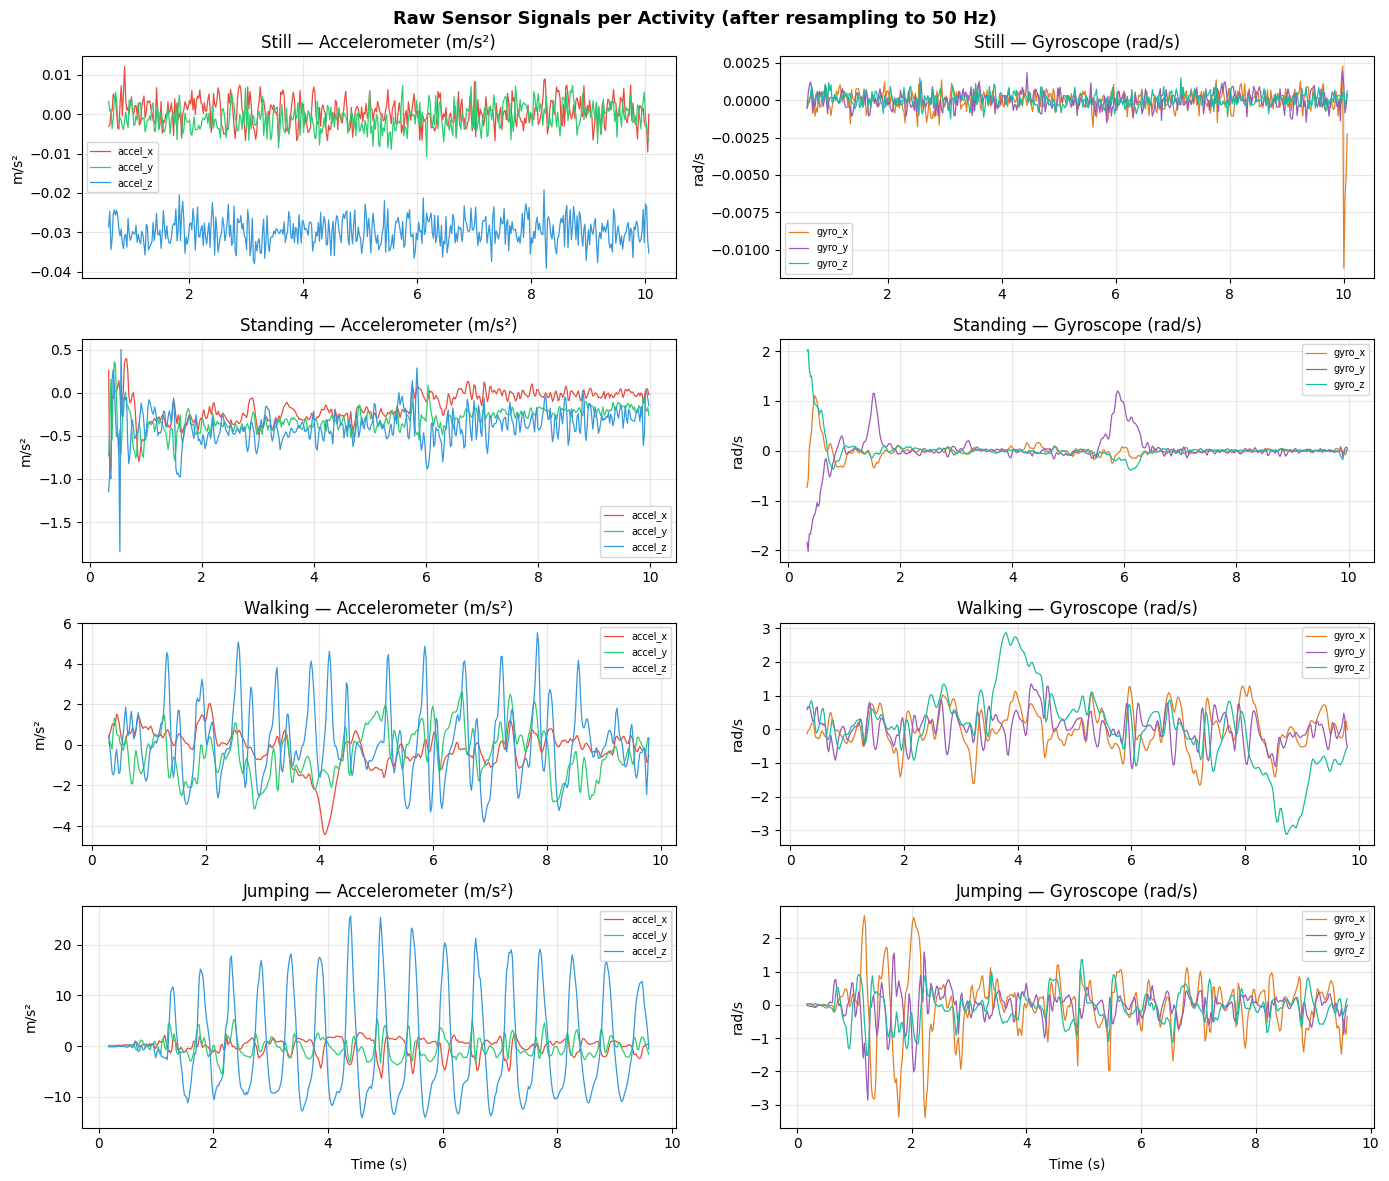

Figure saved as raw_signals.png


In [34]:
# Collect one sample path per activity
activity_samples = {a: [] for a in ACTIVITIES}
for s_dir, label, _ in train_samples:
    activity_samples[label].append(s_dir)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle('Raw Sensor Signals per Activity (after resampling to 50 Hz)',
             fontsize=13, fontweight='bold')

colors = {
    'accel_x': '#e74c3c', 'accel_y': '#2ecc71', 'accel_z': '#3498db',
    'gyro_x' : '#e67e22', 'gyro_y' : '#9b59b6', 'gyro_z' : '#1abc9c'
}

for row, activity in enumerate(ACTIVITIES):
    if not activity_samples[activity]:
        continue
    result = load_recording(activity_samples[activity][0])
    if result is None:
        continue
    df, _, _ = result

    ax_a = axes[row, 0]
    ax_g = axes[row, 1]

    for col in ['accel_x', 'accel_y', 'accel_z']:
        ax_a.plot(df['t'], df[col], label=col,
                  color=colors[col], linewidth=0.9)
    ax_a.set_title(f'{activity.capitalize()} — Accelerometer (m/s²)')
    ax_a.set_ylabel('m/s²')
    ax_a.legend(fontsize=7)
    ax_a.grid(True, alpha=0.3)

    for col in ['gyro_x', 'gyro_y', 'gyro_z']:
        ax_g.plot(df['t'], df[col], label=col,
                  color=colors[col], linewidth=0.9)
    ax_g.set_title(f'{activity.capitalize()} — Gyroscope (rad/s)')
    ax_g.set_ylabel('rad/s')
    ax_g.legend(fontsize=7)
    ax_g.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as raw_signals.png")

---
## Section 2 — Feature Extraction

### 2.1 Feature Functions

We extract **58 features** per window

In [35]:
def extract_features(window_df, fs=TARGET_FS):
    """
    Extract time domain and frequency domain features from one window.
    Returns a 1-D numpy array of length 58.
    """
    axes_list = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
    features  = []
    signals   = {a: window_df[a].values for a in axes_list}

    # Time domain: mean, variance, std, RMS
    for ax in axes_list:
        s = signals[ax]
        features.append(np.mean(s))                   # mean
        features.append(np.var(s))                    # variance
        features.append(np.std(s))                    # standard deviation
        features.append(np.sqrt(np.mean(s ** 2)))     # RMS

    # Signal Magnitude Area (SMA)
    sma_accel = (np.sum(np.abs(signals['accel_x']) +
                        np.abs(signals['accel_y']) +
                        np.abs(signals['accel_z'])) / len(signals['accel_x']))
    sma_gyro  = (np.sum(np.abs(signals['gyro_x'])  +
                        np.abs(signals['gyro_y'])  +
                        np.abs(signals['gyro_z']))  / len(signals['gyro_x']))
    features.append(sma_accel)
    features.append(sma_gyro)

    # Cross-axis correlations
    pairs = [
        ('accel_x','accel_y'), ('accel_x','accel_z'), ('accel_y','accel_z'),
        ('gyro_x', 'gyro_y'),  ('gyro_x', 'gyro_z'),  ('gyro_y', 'gyro_z')
    ]
    for a1, a2 in pairs:
        corr = np.corrcoef(signals[a1], signals[a2])[0, 1]
        features.append(0.0 if np.isnan(corr) else corr)

    #Frequency-domain: dominant frequency & spectral energy (FFT)
    n     = len(signals['accel_x'])
    freqs = fftfreq(n, d=1.0 / fs)[:n // 2]

    for ax in axes_list:
        s        = signals[ax]
        fft_vals = np.abs(fft(s))[:n // 2]

        dom_freq    = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0.0
        spec_energy = np.sum(fft_vals ** 2) / n

        features.append(dom_freq)     # dominant frequency (Hz)
        features.append(spec_energy)  # spectral energy

    return np.array(features, dtype=np.float32)


# Feature names (for labelling plots)
feature_names = []
for ax in ['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z']:
    for stat in ['mean','var','std','rms']:
        feature_names.append(f'{ax}_{stat}')
feature_names += ['sma_acc', 'sma_gyr']
feature_names += ['corr_ax_ay','corr_ax_az','corr_ay_az',
                  'corr_gx_gy','corr_gx_gz','corr_gy_gz']
for ax in ['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z']:
    feature_names += [f'{ax}_domfreq', f'{ax}_energy']

# Sanity check
result = load_recording(train_samples[0][0])
if result:
    df_sample, _, _ = result
    test_feat = extract_features(df_sample.iloc[:WINDOW_SIZE])
    print(f"Feature vector length : {len(test_feat)}  (expected 44)")
    print(f"Feature names count   : {len(feature_names)}")

Feature vector length : 44  (expected 44)
Feature names count   : 44


### 2.2 Sliding-Window Extraction Pipeline

In [36]:
def extract_all_features(sample_list, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Process all recordings in sample_list using a sliding window.
    Returns:
        X       - (N, 58) feature matrix
        y       - (N,)    integer activity labels
        lengths - list of window counts per recording (required by hmmlearn)
    """
    all_features, all_labels, lengths = [], [], []
    skipped = 0

    for s_dir, label, participant in sample_list:
        result = load_recording(s_dir)
        if result is None:
            skipped += 1
            continue
        df, _, _ = result

        if len(df) < window_size:
            skipped += 1
            continue

        seq_features = []
        for start in range(0, len(df) - window_size + 1, step):
            window = df.iloc[start:start + window_size]
            feat   = extract_features(window)
            seq_features.append(feat)
            all_labels.append(ACTIVITY_TO_ID[label])

        all_features.extend(seq_features)
        lengths.append(len(seq_features))

    if skipped:
        print(f"  Skipped {skipped} recordings (missing files or too short).")

    return np.array(all_features), np.array(all_labels), lengths


print("Extracting training features...")
X_train, y_train, train_lengths = extract_all_features(train_samples)
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  sequences: {len(train_lengths)}")

print("\nExtracting test features...")
X_test, y_test, test_lengths = extract_all_features(test_samples)
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

Extracting training features...
  X_train : (762, 44)
  y_train : (762,)
  sequences: 40

Extracting test features...
  X_test  : (464, 44)
  y_test  : (464,)


### 2.3 Z-Score Normalisation

In [37]:
# Z-score normalisation chosen because:
#  Features have very different scales (m/s² vs rad/s vs Hz)
#  Z-score centres each feature at 0 with std=1
#  Scaler is fit ONLY on training data to avoid data leakage

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Z-score normalisation applied.")
print(f"  Train — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"  Test  — mean: {X_test_scaled.mean():.4f}  std: {X_test_scaled.std():.4f}")

Z-score normalisation applied.
  Train — mean: 0.0000  std: 1.0000
  Test  — mean: -0.0565  std: 0.9866


### 2.4 Feature Distribution Visualisation

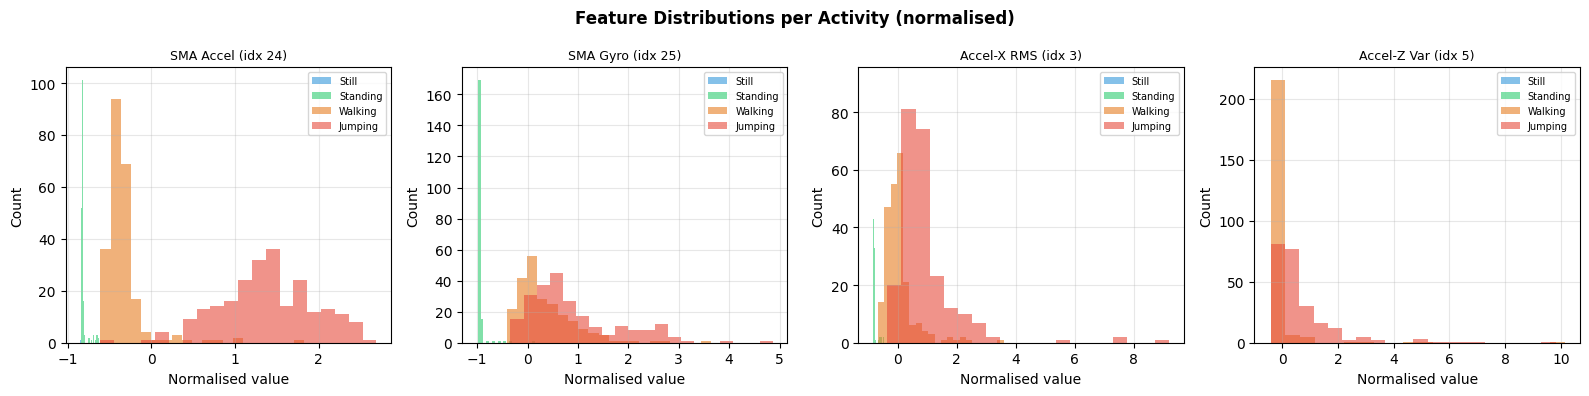

Saved feature_distributions.png


In [38]:
# Plot distribution of 4 key features across activities
key_features = {
    'SMA Accel (idx 24)'    : 24,
    'SMA Gyro (idx 25)'     : 25,
    'Accel-X RMS (idx 3)'   : 3,
    'Accel-Z Var (idx 5)'   : 5
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Feature Distributions per Activity (normalised)',
             fontsize=12, fontweight='bold')

activity_colors = {
    'still': '#3498db', 'standing': '#2ecc71',
    'walking': '#e67e22', 'jumping': '#e74c3c'
}

for ax, (fname, fidx) in zip(axes, key_features.items()):
    for act_id, act_name in ID_TO_ACTIVITY.items():
        vals = X_train_scaled[y_train == act_id, fidx]
        ax.hist(vals, bins=20, alpha=0.6,
                label=act_name.capitalize(),
                color=activity_colors[act_name])
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel('Normalised value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved feature_distributions.png")

## Section 3 — Hidden Markov Model (HMM) Activity Classification

Human activities occur as temporal sequences, where the current motion depends on the previous motion state.
Hidden Markov Models are well-suited for this problem because they model:


*  Hidden states (the underlying activity patterns)

*  Observation probabilities (sensor features)
*  State transitions over time

Instead of training one model for all activities, we train one HMM per activity class and classify new samples using maximum likelihood.

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.1 Train One HMM per Activity

In [41]:
# -------------------------------------------------------
# TRAIN HMM MODELS (one model per activity)
# -------------------------------------------------------

models = {}

n_states = 4   # number of hidden states inside each activity model

for activity, act_id in ACTIVITY_TO_ID.items():

    print(f"Training HMM for: {activity}")

    # Select training windows belonging to this activity
    X_act = X_train_scaled[y_train == act_id]

    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=200,
        random_state=42
    )

    model.fit(X_act)

    models[activity] = model

print("\nTraining complete.")

Training HMM for: still
Training HMM for: standing
Training HMM for: walking
Training HMM for: jumping

Training complete.


## 3.2 Activity Prediction Function

The classifier evaluates which model assigns the highest likelihood to the input features.

In [45]:
# -------------------------------------------------------
# PREDICTION FUNCTION
# -------------------------------------------------------

def predict_activity(sample):

    scores = {}

    for activity, model in models.items():

        score = model.score(sample.reshape(1, -1))

        scores[activity] = score

    return max(scores, key=scores.get)

## 3.3 Run Predictions on Test Data

In [46]:
# -------------------------------------------------------
# RUN PREDICTIONS
# -------------------------------------------------------

predictions = []

for sample in X_test_scaled:

    pred = predict_activity(sample)

    predictions.append(pred)

true_labels = [ID_TO_ACTIVITY[i] for i in y_test]

## 3.4 Confusion Matrix

The confusion matrix shows how well the classifier distinguishes activities.

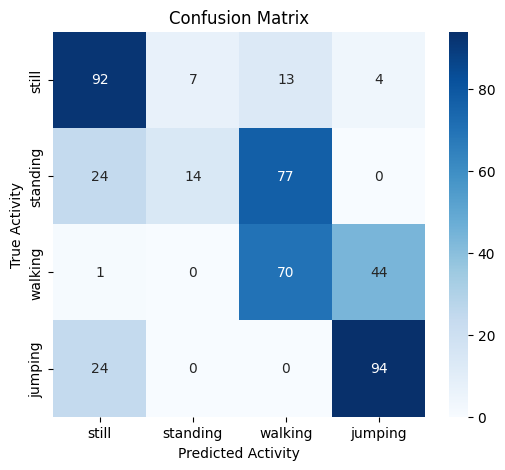

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predictions, labels=ACTIVITIES)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ACTIVITIES,
    yticklabels=ACTIVITIES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")

plt.show()

## 3.5 Accuracy and Classification Report

In [48]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(true_labels, predictions)

print(f"Overall Accuracy: {accuracy:.3f}\n")

print("Classification Report:\n")

print(
classification_report(
    true_labels,
    predictions,
    target_names=ACTIVITIES
)
)

Overall Accuracy: 0.582

Classification Report:

              precision    recall  f1-score   support

       still       0.66      0.80      0.72       118
    standing       0.67      0.12      0.21       115
     walking       0.65      0.79      0.72       116
     jumping       0.44      0.61      0.51       115

    accuracy                           0.58       464
   macro avg       0.60      0.58      0.54       464
weighted avg       0.61      0.58      0.54       464



## 3.6 Sensitivity and Specificity

Sensitivity and specificity give deeper insight into classification performance.

In [49]:
def compute_metrics(cm):

    metrics = []

    for i in range(len(cm)):

        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FP + FN)

        sensitivity = TP / (TP + FN)
        specificity = TN / (TN + FP)

        metrics.append((sensitivity, specificity))

    return metrics


metrics = compute_metrics(cm)

for i, activity in enumerate(ACTIVITIES):

    sens, spec = metrics[i]

    print(activity)
    print("Sensitivity:", round(sens,3))
    print("Specificity:", round(spec,3))
    print()

still
Sensitivity: 0.793
Specificity: 0.859

standing
Sensitivity: 0.122
Specificity: 0.98

walking
Sensitivity: 0.609
Specificity: 0.742

jumping
Sensitivity: 0.797
Specificity: 0.861



## 3.7 Visualising HMM Emission Means

This plot helps interpret how each hidden state models the sensor features.

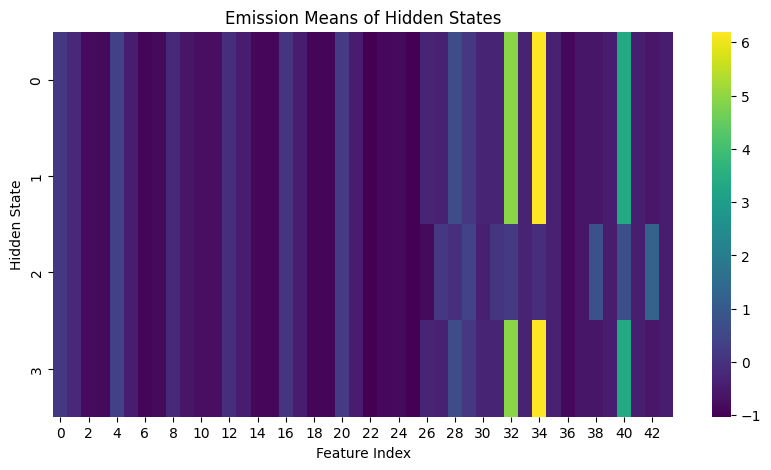

In [50]:
plt.figure(figsize=(10,5))

sns.heatmap(
    list(models.values())[0].means_,
    cmap="viridis"
)

plt.title("Emission Means of Hidden States")
plt.xlabel("Feature Index")
plt.ylabel("Hidden State")

plt.show()

## 3.8 Decoded Activity Sequence (Viterbi)

Viterbi Algorithm finds the most probable hidden state sequence.

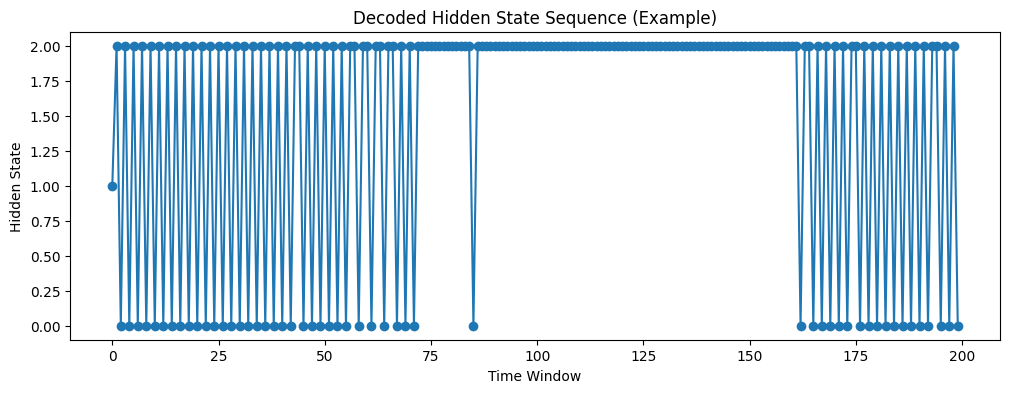

In [51]:
example_model = list(models.values())[0]

predicted_states = example_model.predict(X_test_scaled[:200])

plt.figure(figsize=(12,4))

plt.plot(predicted_states, marker="o")

plt.title("Decoded Hidden State Sequence (Example)")
plt.xlabel("Time Window")
plt.ylabel("Hidden State")

plt.show()